In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make plots look a bit bigger
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
DATA_PATH = 'monthly_milk_production.csv'
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')
df.index.freq = 'MS'  # Month Start
df.columns = ['production']
df.head()

,production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


Let's look at the line going up and down (the time series).

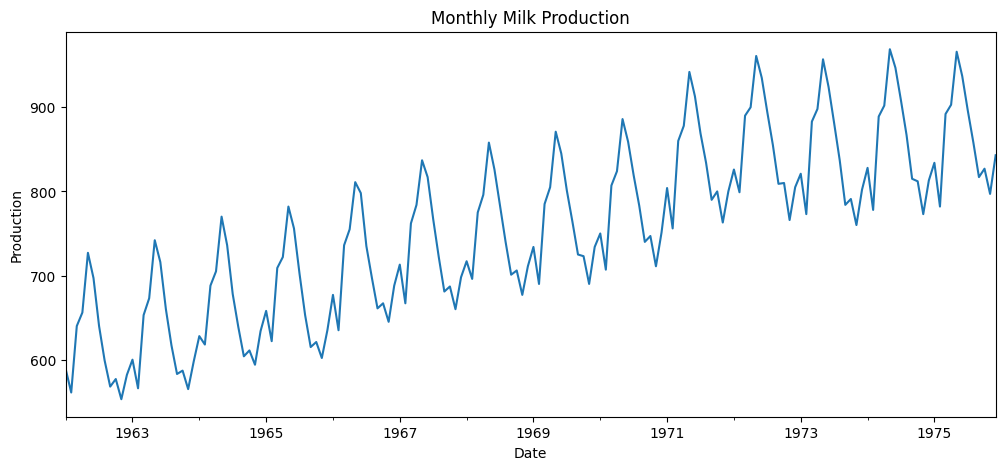

In [4]:
df['production'].plot()
plt.title('Monthly Milk Production')
plt.xlabel('Date')
plt.ylabel('Production')
plt.show()

## 2) Train/Test split
We teach the model using older months (**train**) and check it on the last months (**test**).

In [5]:
# Use the last 12 months for testing
TEST_SIZE = 12
train = df.iloc[:-TEST_SIZE].copy()
test  = df.iloc[-TEST_SIZE:].copy()

len(train), len(test), train.head(), test.head()

(156,
 12,
             production
 Date                  
 1962-01-01         589
 1962-02-01         561
 1962-03-01         640
 1962-04-01         656
 1962-05-01         727,
             production
 Date                  
 1975-01-01         834
 1975-02-01         782
 1975-03-01         892
 1975-04-01         903
 1975-05-01         966)

## 3) Scale numbers (Min-Max)
Neural networks learn better when numbers are squished into a small range like 0 to 1.

We **hardcode** a tiny Min-Max scaler using only NumPy.

In [6]:

class MinMaxScalerNumpy:
    def __init__(self):
        self.data_min_ = None
        self.data_max_ = None

    def fit(self, x):
        x = np.asarray(x, dtype=float)
        self.data_min_ = x.min()
        self.data_max_ = x.max()
        if self.data_max_ == self.data_min_:
            # avoid divide-by-zero
            self.data_max_ = self.data_min_ + 1.0
        return self

    def transform(self, x):
        x = np.asarray(x, dtype=float)
        return (x - self.data_min_) / (self.data_max_ - self.data_min_)

    def inverse_transform(self, x_scaled):
        x_scaled = np.asarray(x_scaled, dtype=float)
        return x_scaled * (self.data_max_ - self.data_min_) + self.data_min_


In [7]:
scaler = MinMaxScalerNumpy().fit(train['production'].values)
scaled_train = scaler.transform(train['production'].values)
scaled_test  = scaler.transform(test['production'].values)

scaled_train[:5], scaled_test[:5]

(array([0.08653846, 0.01923077, 0.20913462, 0.24759615, 0.41826923]),
 array([0.67548077, 0.55048077, 0.81490385, 0.84134615, 0.99278846]))

## 4) Make sequences (like sliding windows)
We will use the last **12 months** to predict the next month.

Like this:
- Input: months 1..12
- Output: month 13

We build many such examples from the training data.

In [8]:

def make_sequences(series_1d, n_input):
    """series_1d: shape (T,) -> returns X (N,n_input,1), y (N,1)"""
    series_1d = np.asarray(series_1d, dtype=float).reshape(-1)
    X, y = [], []
    for i in range(len(series_1d) - n_input):
        X.append(series_1d[i:i+n_input])
        y.append(series_1d[i+n_input])
    X = np.array(X).reshape(-1, n_input, 1)
    y = np.array(y).reshape(-1, 1)
    return X, y

n_input = 12
X_train, y_train = make_sequences(scaled_train, n_input)
X_train.shape, y_train.shape


((144, 12, 1), (144, 1))

## 5) The Memory Model: a Simple RNN (made with NumPy)
An RNN reads numbers one-by-one and keeps a **hidden memory**.

Math idea (don’t worry, we code it):
- hidden = tanh(Wxh * x + Whh * hidden + bh)
- y_hat  = Why * hidden + by

We train it using **Backpropagation Through Time (BPTT)** (the RNN remembers and learns).

In [9]:

def tanh(x):
    return np.tanh(x)

def dtanh(y):
    # derivative of tanh, using output y = tanh(x)
    return 1.0 - y**2

class SimpleRNNRegressor:
    def __init__(self, n_features, hidden_size, lr=0.01, seed=42, clip=1.0):
        rng = np.random.default_rng(seed)
        self.n_features = n_features
        self.hidden_size = hidden_size
        self.lr = lr
        self.clip = clip

        # Weight shapes:
        # Wxh: (hidden, input_features)
        # Whh: (hidden, hidden)
        # Why: (output=1, hidden)
        self.Wxh = rng.normal(0, 0.1, size=(hidden_size, n_features))
        self.Whh = rng.normal(0, 0.1, size=(hidden_size, hidden_size))
        self.bh  = np.zeros((hidden_size, 1))

        self.Why = rng.normal(0, 0.1, size=(1, hidden_size))
        self.by  = np.zeros((1, 1))

    def forward(self, X_seq):
        """X_seq: (T, n_features) -> returns y_hat (1,1) and cache for backprop"""
        T = X_seq.shape[0]
        hs = np.zeros((T+1, self.hidden_size, 1))
        xs = np.zeros((T, self.n_features, 1))

        for t in range(T):
            x_t = X_seq[t].reshape(self.n_features, 1)
            xs[t] = x_t
            hs[t+1] = tanh(self.Wxh @ x_t + self.Whh @ hs[t] + self.bh)

        y_hat = self.Why @ hs[T] + self.by  # use last hidden state
        cache = (xs, hs)
        return y_hat, cache

    def backward(self, dy, cache):
        """dy: dLoss/dy_hat shape (1,1)"""
        xs, hs = cache
        T = xs.shape[0]

        # Gradients init
        dWhy = dy @ hs[T].T
        dby  = dy

        dh_next = self.Why.T @ dy  # gradient flowing into last hidden

        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dbh  = np.zeros_like(self.bh)

        for t in reversed(range(T)):
            h_t = hs[t+1]         # (hidden,1)
            h_prev = hs[t]        # (hidden,1)
            x_t = xs[t]           # (n_features,1)

            # back through tanh
            dh_raw = dh_next * dtanh(h_t)  # (hidden,1)

            dbh  += dh_raw
            dWxh += dh_raw @ x_t.T
            dWhh += dh_raw @ h_prev.T

            # pass gradient to previous hidden
            dh_next = self.Whh.T @ dh_raw

        # Clip gradients to avoid exploding
        for g in [dWxh, dWhh, dbh, dWhy, dby]:
            np.clip(g, -self.clip, self.clip, out=g)

        grads = (dWxh, dWhh, dbh, dWhy, dby)
        return grads

    def step(self, grads):
        dWxh, dWhh, dbh, dWhy, dby = grads
        self.Wxh -= self.lr * dWxh
        self.Whh -= self.lr * dWhh
        self.bh  -= self.lr * dbh
        self.Why -= self.lr * dWhy
        self.by  -= self.lr * dby

    def fit(self, X, y, epochs=200, verbose_every=20):
        losses = []
        for ep in range(1, epochs+1):
            total_loss = 0.0

            # simple SGD over samples
            for i in range(X.shape[0]):
                X_seq = X[i]  # (T,1)
                y_true = y[i].reshape(1,1)

                y_hat, cache = self.forward(X_seq)

                # MSE loss: (y_hat - y)^2
                err = y_hat - y_true
                loss = float((err**2).mean())
                total_loss += loss

                # dLoss/dy_hat for MSE: 2*(y_hat - y)/1
                dy = 2.0 * err

                grads = self.backward(dy, cache)
                self.step(grads)

            avg_loss = total_loss / X.shape[0]
            losses.append(avg_loss)
            if verbose_every and (ep % verbose_every == 0 or ep == 1):
                print(f"Epoch {ep:4d} | loss {avg_loss:.6f}")
        return losses

    def predict_one(self, X_seq):
        y_hat, _ = self.forward(X_seq)
        return float(y_hat.squeeze())


## 6) Train the RNN
We will keep the memory size small so it learns fast.
If the loss goes down, the model is learning (yay!).

Epoch    1 | loss 0.028522
Epoch   50 | loss 0.009515
Epoch  100 | loss 0.008980
Epoch  150 | loss 0.008801
Epoch  200 | loss 0.007880
Epoch  250 | loss 0.005336
Epoch  300 | loss 0.004667


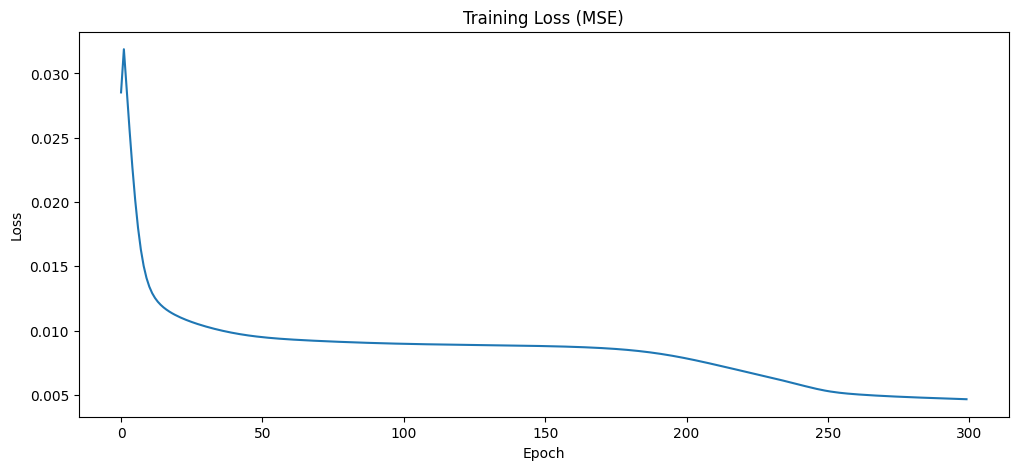

In [10]:

rnn = SimpleRNNRegressor(n_features=1, hidden_size=16, lr=0.02, clip=1.0, seed=7)

losses = rnn.fit(X_train, y_train, epochs=300, verbose_every=50)

plt.plot(losses)
plt.title('Training Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


## 7) Predict the next 12 months (walk-forward)
We copy how the real world works:
- use the last 12 months
- predict the next month
- slide the window forward
- repeat

In [11]:

# Start with the last n_input points from training
current_window = scaled_train[-n_input:].reshape(n_input, 1)

scaled_preds = []
for _ in range(len(test)):
    pred = rnn.predict_one(current_window)  # one step ahead
    scaled_preds.append(pred)

    # slide: drop oldest, add new prediction
    current_window = np.vstack([current_window[1:], [[pred]]])

scaled_preds = np.array(scaled_preds).reshape(-1, 1)

# Convert back to original units
preds = scaler.inverse_transform(scaled_preds).reshape(-1)

test = test.copy()
test['prediction'] = preds
test


,production,prediction
Date,,
1975-01-01,834,792.728568
1975-02-01,782,787.728375
1975-03-01,892,841.332971
1975-04-01,903,890.739845
1975-05-01,966,923.064353
1975-06-01,937,924.987205
1975-07-01,896,903.448811
1975-08-01,858,861.559216
1975-09-01,817,822.782294


Plot true vs predicted.

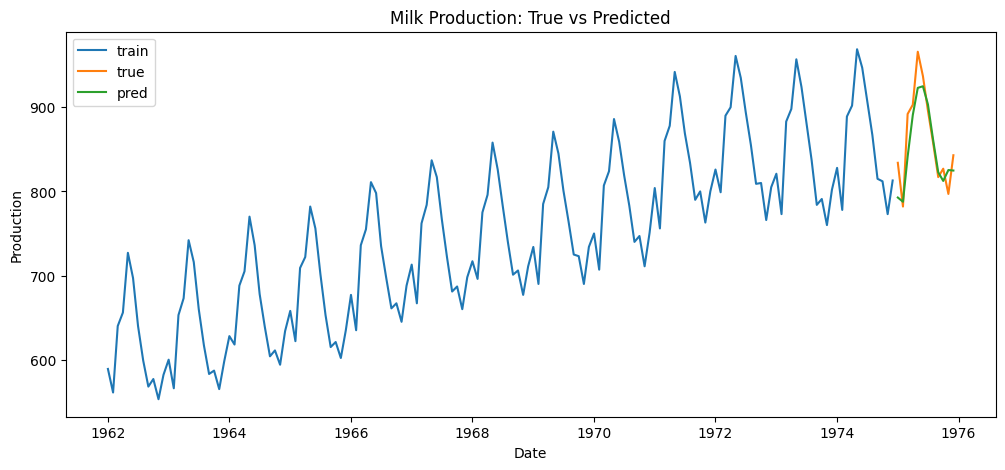

In [12]:

plt.plot(train.index, train['production'], label='train')
plt.plot(test.index, test['production'], label='true')
plt.plot(test.index, test['prediction'], label='pred')
plt.title('Milk Production: True vs Predicted')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.show()


## 8) Evaluate with regression metrics (no sklearn)
We use:
- MAE: average absolute error
- RMSE: like MAE but punishes big mistakes
- R²: 1.0 is perfect, 0.0 is "just guessing the mean"

In [13]:

y_true = test['production'].values.astype(float)
y_pred = test['prediction'].values.astype(float)

mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(np.mean((y_true - y_pred)**2))

# R2 = 1 - SS_res/SS_tot
ss_res = np.sum((y_true - y_pred)**2)
ss_tot = np.sum((y_true - np.mean(y_true))**2)
r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

mae, rmse, r2


(np.float64(20.233584713496317),
 np.float64(25.645166160048642),
 np.float64(0.7758479568898363))

## 9) Save the trained model (NumPy .npz)
So a small web app can load it later.

In [15]:

MODEL_PATH = 'rnn_milk_model.npz'
np.savez(
    MODEL_PATH,
    Wxh=rnn.Wxh, Whh=rnn.Whh, bh=rnn.bh,
    Why=rnn.Why, by=rnn.by,
    data_min=scaler.data_min_, data_max=scaler.data_max_,
    n_input=n_input
)
MODEL_PATH


'rnn_milk_model.npz'